In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Data Import and Exploration

In [2]:
# Reading in example response times (RT) data
df = pd.read_csv("WritingStudyFastSlow_long.csv", sep=";")

In [3]:
# Explore the top five rows
df.head()

,participant,condition,char,RT
0,AMS_04142025,D_fast,C,169
1,AMS_04142025,ND_fast,C,422
2,APM_04072025,D_fast,C,453
3,APM_04072025,ND_fast,C,591
4,ARI_04162025,D_fast,C,372


Text(0, 0.5, 'Frequency')

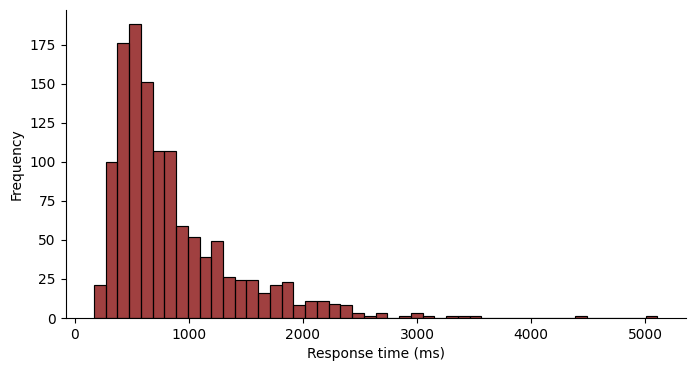

In [4]:
# Simple way to create a nice histogram of all RTs
rts = df.RT.values
f, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.histplot(rts, color='maroon', ax=ax)
sns.despine(ax=ax)
ax.set_xlabel('Response time (ms)')
ax.set_ylabel('Frequency')

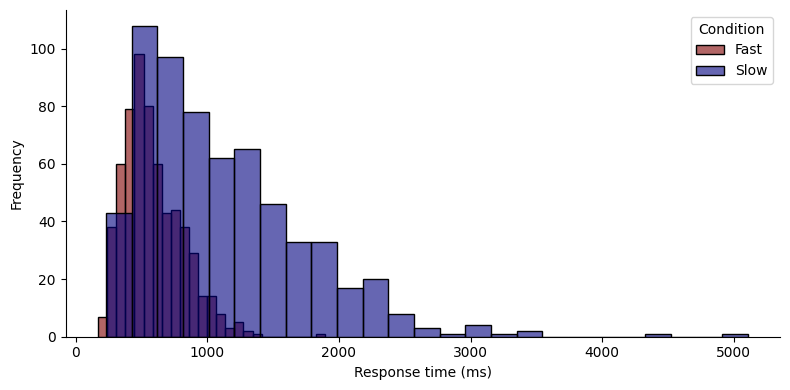

In [8]:
# Plot RTs for fast and slow conditions separately
rts_fast = df.RT[df.condition.str.contains('fast')].values
rts_slow = df.RT[df.condition.str.contains('slow')].values

f, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.histplot(rts_fast, color='maroon', alpha=0.6, ax=ax, label='Fast')
sns.histplot(rts_slow, color='navy', alpha=0.6, ax=ax, label='Slow')
sns.despine(ax=ax)
ax.set_xlabel('Response time (ms)')
ax.set_ylabel('Frequency')
ax.legend(title='Condition')

f.tight_layout()

## Simulating the Drift Diffusion Model

As we discussed in class, the Drift Diffusion Model (DDM) is a widely used cognitive process model for decision-making in two-alternative forced-choice tasks. It conceptualizes decision-making as a noisy accumulation of evidence over time, with a decision reached when the accumulated evidence crosses a threshold. The DDM captures key behavioral measures, such as accuracy and response times, and provides insights into cognitive processes like speed-accuracy trade-offs. This notebook simulates the DDM and explores its fundamental properties.

In [ ]:
# The simulation might not use the entire 10,000 time steps if drift rate is high and decision is made early
def ddm_trial(v, a, beta, tau, dt=1e-3, scale=1.0, max_time=10.):
    """
    Simulates one realization of the diffusion process given
    a set of parameters and a step size `dt`.

    Parameters:
    -----------
    v     : float
        The drift rate (rate of information uptake)
    a     : float
        The boundary separation (decision threshold).
    beta  : float in [0, 1]
        Relative starting point (prior option preferences)
    tau   : float
        Non-decision time (additive constant)
    dt    : float, optional (default: 1e-3 = 0.001)
        The step size for the Euler algorithm.
    scale : float, optional (default: 1.0)
        The scale (sqrt(var)) of the Wiener process. Not considered
        a parameter and typically fixed to either 1.0 or 0.1.
    max_time: float, optional (default: .10)
        The maximum number of seconds before forced termination.

    Returns:
    --------
    (x, c) - a tuple of response time (y - float) and a 
        binary decision (c - int) 
    """

    # x = np.zeros(max_time/dt)
    # x[0] = beta

    x = beta * a # (not just beta bc need to scale w.r.t to boundary)
    t = 0

    while t < max_time :
        # We times the sqrt(dt) to the scale here to match euler-maruyama method
        # This is the formulation that allows us to discretize dt since it's incremental
        x += v * dt + scale * np.sqrt(dt) * np.random.standard_normal()
        if x >= a:
            c = 1
            return (t + tau, c)
        if x <= 0:
            c = 0
            return (t + tau, c)
        t = t + dt

    return (max_time, [1 if x[-1] > 0 else 0])


def ddm(num_sims, v, a, beta, tau, dt=1e-3, scale=1.0, max_time=10.):
    """Add a nice docstring."""

    data = np.zeros((num_sims, 2))
    for n in range(num_sims):
        data[n, :] = ddm_trial(v, a, beta, tau, dt, scale, max_time)
    return data


def visualize_diffusion_model(data, figsize=(8, 6)):
    """TODO: Add a nice docstring."""
    f, ax = plt.subplots(1, 1, figsize=figsize)
    sns.histplot(data[:, 0][data[:, 1] == 1], color='maroon', alpha=0.7, ax=ax, label='Correct responses')
    sns.histplot(data[:, 0][data[:, 1] == 0], color='gray', ax=ax, label='Incorrect responses')
    sns.despine(ax=ax)
    ax.set_xlabel('Response time (s)', fontsize=18)
    ax.set_ylabel('')
    ax.legend(fontsize=18)
    ax.set_yticks([])
    return f

In [ ]:
params = {
    'v': 1,
    'a': 3,
    'beta': 0.5,
    'tau': 0.7
}

In [ ]:
ddm_data = ddm(1000, **params)

In [ ]:
f = visualize_diffusion_model(ddm_data)